#### ***Product Segmentation - Hierarchical Clustering***

***Context***

*Extract insights from the data of men's and women's shoes, and grouping products together to identify similarities and differences between the product range of these renowned brands.*

***Objective***

*To perform an exploratory data analysis and cluster the products based on various factors*

***Data Description***

*The dataset consists of 3268 products from Nike and Adidas with features of information including their ratings, discount, sales price, listed price, product name, and the number of reviews.*

*`Product Name`: Name of the product*<br>
*`Product ID`: ID of the product*<br>
*`Listing Price`: Listed price of the product*<br>
*`Sale Price`: Sale price of the product*<br>
*`Discount`: Percentage of discount on the product*<br>
*`Brand`: Brand of the product*<br>
*`Rating`: Rating of the product*<br>
*`Reviews`: Number of reviews for the product*

#### ***Import Libraries***

In [1]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to compute distances between all pairs of rows in a dataframe
from scipy.spatial.distance import pdist

# to perform hierarchical clustering, compute cophenetic correlation, and create dendrograms
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

In [2]:
# loading the dataset
data = pd.read_csv("data/37_data_add_nik.csv")

In [3]:
data.shape

(3268, 8)

***The dataset has 3268 rows and 8 columns*** 

In [4]:
# viewing a random sample of the dataset
data.sample(n=10, random_state=1)

,Product Name,Product ID,Listing Price,Sale Price,Discount,Brand,Rating,Reviews
255,Women's adidas Originals POD-S3.1 Shoes,CG6188,13999,6999,50,Adidas ORIGINALS,3.3,8
1551,Men's adidas Originals Superstar Pure Shoes,FV3013,11999,11999,0,Adidas ORIGINALS,3.9,10
1352,Men's adidas Originals Superstar Shoes,FV2806,7999,7999,0,Adidas ORIGINALS,4.4,42
1060,Men's adidas Football Nemeziz 19.3 Indoor Shoes,F34411,5999,3599,40,Adidas SPORT PERFORMANCE,4.5,75
808,Men's adidas Sport Inspired Court 80s Shoes,EE9676,5999,3599,40,Adidas CORE / NEO,4.5,55
836,Men's adidas Running Stargon 1.0 Shoes,CM4935,4799,3839,20,Adidas CORE / NEO,3.5,21
2107,Men's adidas Originals Yung-96 Chasm Shoes,EE7238,7999,4799,40,Adidas ORIGINALS,3.0,62
3002,Nike SB Air Max Stefan Janoski 2,AQ7477-009,0,9995,0,Nike,2.6,11
2329,Men's adidas Originals Rivalry Low Shoes,FV4287,10999,10999,0,Adidas ORIGINALS,2.8,8
602,Men's adidas Sport Inspired Lite Racer RBN Shoes,F36642,5599,3919,30,Adidas CORE / NEO,3.0,56


In [5]:
# copying the data to another variable to avoid any changes to original data
df = data.copy()

In [6]:
# fixing column names
df.columns = [c.replace(" ", "_") for c in df.columns]

In [7]:
# let's look at the structure of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3268 entries, 0 to 3267
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product_Name   3268 non-null   object 
 1   Product_ID     3268 non-null   object 
 2   Listing_Price  3268 non-null   int64  
 3   Sale_Price     3268 non-null   int64  
 4   Discount       3268 non-null   int64  
 5   Brand          3268 non-null   object 
 6   Rating         3268 non-null   float64
 7   Reviews        3268 non-null   int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 204.4+ KB


***Dropping Product_ID column***

In [8]:
df.drop("Product_ID", axis=1, inplace=True)

In [9]:
# let's check for duplicate observations
df.duplicated().sum()

np.int64(117)

***There are 117 duplicate observations. We will remove them from the data.***

In [10]:
df = df[(~df.duplicated())].copy()

**Let's take a look at the summary of the data**

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Listing_Price,3151.0,7045.960330,4652.089511,0.0,4599.0,5999.0,8999.0,29999.0
Sale_Price,3151.0,5983.166931,4173.708897,449.0,2999.0,4599.0,7799.0,36500.0
Discount,3151.0,27.860997,22.442753,0.0,0.0,40.0,50.0,60.0
Rating,3151.0,3.285687,1.371611,0.0,2.6,3.6,4.4,5.0
Reviews,3151.0,41.891146,31.283464,0.0,12.0,40.0,69.0,223.0


***Observations***

`Listing_Price` 0 means missing values. Average is more than Median, indicating outliers<br>
`Sale_Price` Average is more than Median, indicating outliers<br>
`Discount` The average discount is 28%.<br>
The average `Rating` is 3.3.<br>
The average number of `Reviews` is 42.

In [12]:
# let's check how many products have listing price 0
(df.Listing_Price == 0).sum()

np.int64(336)

In [13]:
# let's check the products which have listing price 0
df[(df.Listing_Price == 0)]

,Product_Name,Listing_Price,Sale_Price,Discount,Brand,Rating,Reviews
2625,Nike Air Force 1 '07 Essential,0,7495,0,Nike,0.0,0
2626,Nike Air Force 1 '07,0,7495,0,Nike,0.0,0
2627,Nike Air Force 1 Sage Low LX,0,9995,0,Nike,0.0,0
2628,Nike Air Max Dia SE,0,9995,0,Nike,0.0,0
2629,Nike Air Max Verona,0,9995,0,Nike,0.0,0
...,...,...,...,...,...,...,...
3254,Nike Mercurial Vapor 13 Club MG,0,4995,0,Nike,0.0,0
3257,Air Jordan 5 Retro,0,15995,0,Nike,3.3,3
3260,Nike Tiempo Legend 8 Academy TF,0,6495,0,Nike,0.0,0
3262,Nike React Metcon AMP,0,13995,0,Nike,3.0,1


In [14]:
df[(df.Listing_Price == 0)].describe().T

,count,mean,std,min,25%,50%,75%,max
Listing_Price,336.0,0.000000,0.000000,0.0,0.0,0.00,0.0,0.0
Sale_Price,336.0,11203.050595,4623.825788,1595.0,7995.0,10995.00,13995.0,36500.0
Discount,336.0,0.000000,0.000000,0.0,0.0,0.00,0.0,0.0
Rating,336.0,2.797619,2.150445,0.0,0.0,3.95,4.7,5.0
Reviews,336.0,8.261905,19.708393,0.0,0.0,1.00,6.0,223.0


*There are 336 rows (which is close to 10% of the given data) where Listing Price is missing, Lets explore other details when Listing Price is zero*

In [15]:
df.loc[(df.Listing_Price == 0), ["Listing_Price"]] = df.loc[
    (df.Listing_Price == 0), ["Sale_Price"]
].values

In [16]:
df.Listing_Price.describe()

count     3151.000000
mean      8240.573151
std       4363.018245
min        899.000000
25%       4999.000000
50%       7599.000000
75%      10995.000000
max      36500.000000
Name: Listing_Price, dtype: float64

In [17]:
# checking missing values
df.isna().sum()

Product_Name     0
Listing_Price    0
Sale_Price       0
Discount         0
Brand            0
Rating           0
Reviews          0
dtype: int64

***No Missing Values***

#### ***Exploratory Data Analysis***

In [18]:
# function to analyze a single numeric feature, creates boxplot, histogram, and CDF
def univariate_num_analysis_box_hist_cdf(data, feature, figsize=(12, 6)):
    """
    Display:
      - Left column: Boxplot (top) and Histogram (bottom)
      - Right column: CDF plot
    for a single numeric feature.
    
    Parameters:
    - data : pandas DataFrame
    - feature : str, numeric column name
    - figsize : tuple, figure size
    """
    fig = plt.figure(figsize=figsize)
    # Create grid: 2 rows, 2 columns
    grid = fig.add_gridspec(2, 2, width_ratios=(3, 2), height_ratios=(0.4, 1))

    # 1Boxplot (top left)
    ax_box = fig.add_subplot(grid[0, 0])
    sns.boxplot(data=data, x=feature, ax=ax_box, showmeans=True, color="lightgreen")
    ax_box.set_title(f'Boxplot of {feature}')

    # Histogram (bottom left)
    ax_hist = fig.add_subplot(grid[1, 0])
    sns.histplot(data=data, x=feature, kde=True, ax=ax_hist, color='skyblue')
    ax_hist.axvline(data[feature].mean(), color="green", linestyle="--", label="Mean")
    ax_hist.axvline(data[feature].median(), color="black", linestyle="-", label="Median")
    ax_hist.set_title(f'Histogram of {feature}')
    ax_hist.legend()

    # CDF Plot (right column, spans both rows)
    ax_cdf = fig.add_subplot(grid[:, 1])  # span both rows in column 2
    sns.ecdfplot(data=data, x=feature, ax=ax_cdf, color='orange')
    ax_cdf.set_title(f'CDF of {feature}')
    ax_cdf.set_ylabel("Cumulative Probability")
    ax_cdf.grid(True)

    plt.tight_layout()
    plt.show()

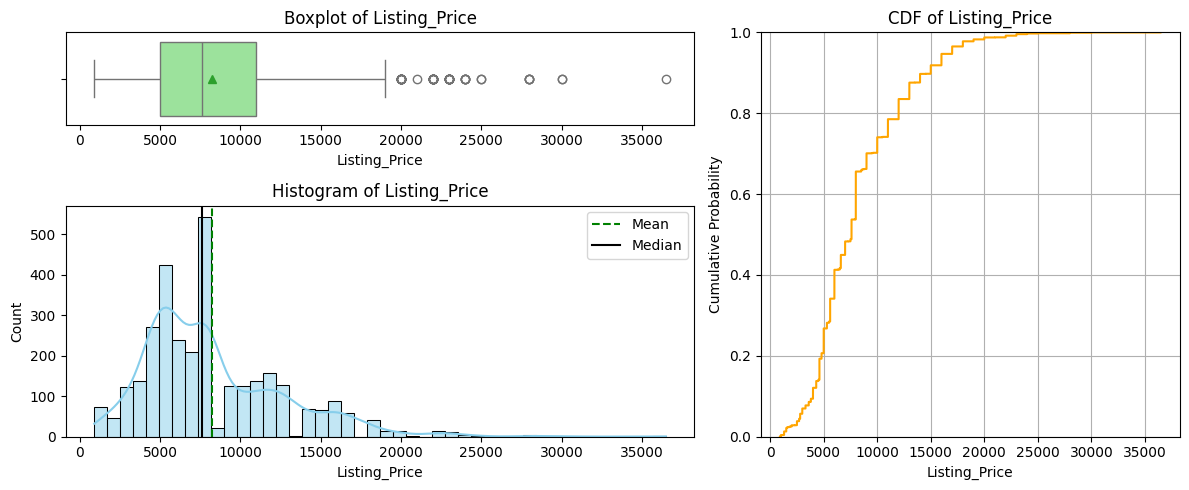

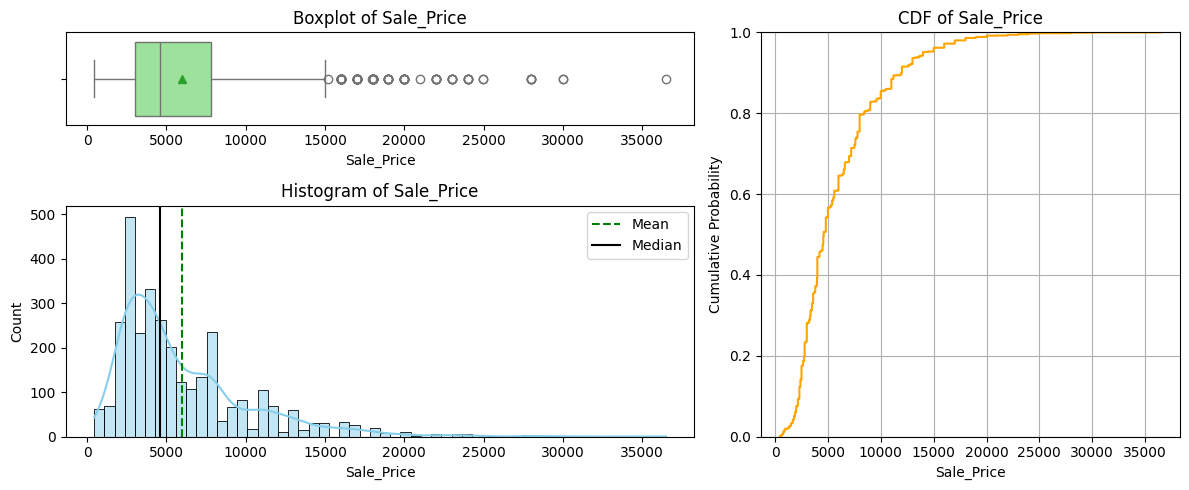

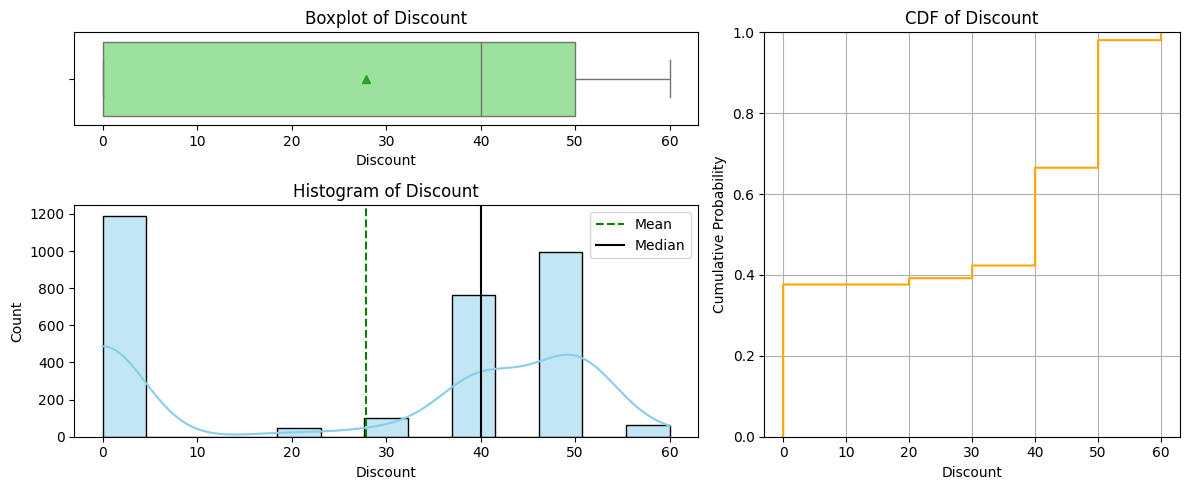

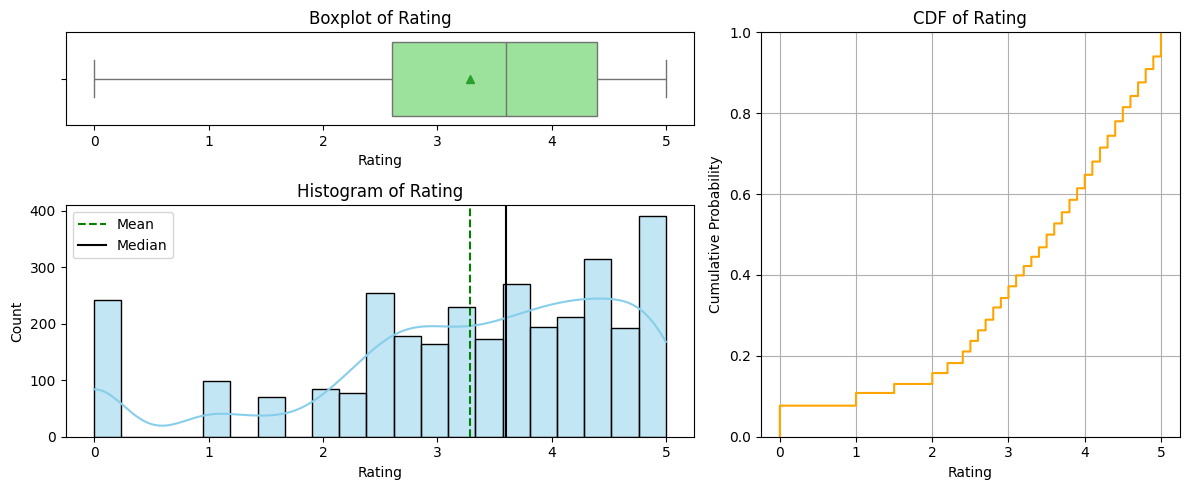

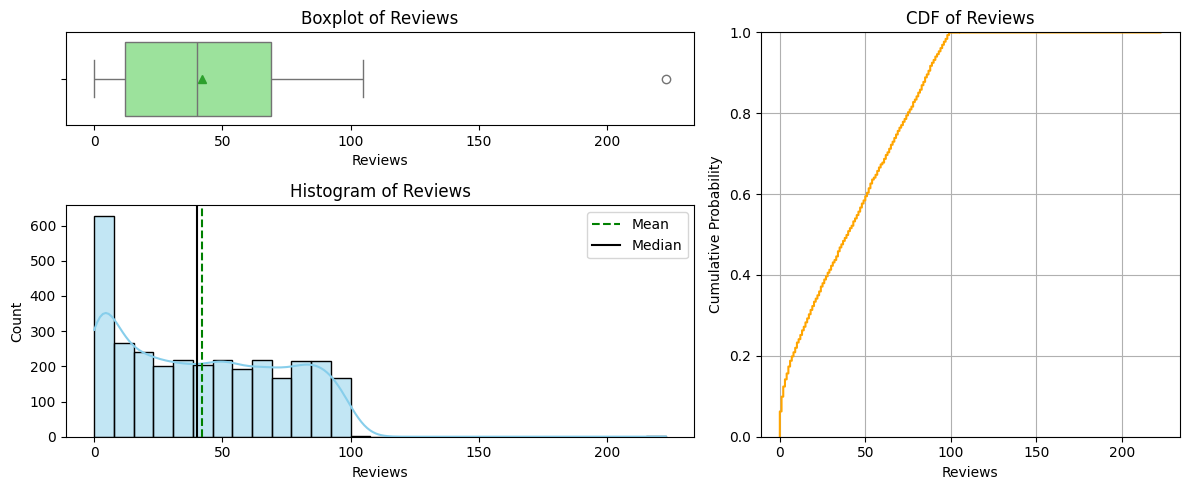

In [19]:
# selecting numerical columns
num_col = df.select_dtypes(include=np.number).columns.tolist()

for item in num_col:
    univariate_num_analysis_box_hist_cdf(df, item, figsize=(12, 5))

***Observations***

`Listing_Price` right skewed, upper outliers, almost 90% listing price less than 15000<br>
`Sale_Price` right skewed, upper outliers, almost 95% of sale price less than 15000<br>
`Discount` Almost 40% products have no discounts.<br>
`Rating` around 40% products have less than 3 rating<br>
`Reviews` Total number of reviews for products are less than 100

In [20]:
# Function to plot count and percentage barplots side by side for categorical features for Univariate Analysis
def cat_analysis_count_and_perct(data, column, figsize=(10, 5)):
    """
    Plots two countplots side by side: one with count labels, one with percentage labels.
    Args:
        data (pd.DataFrame): The DataFrame containing the data.
        column (str): The column to plot.
        figsize (tuple): Figure size for the plots.
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    categories = data[column].value_counts().index
    total = len(data)
    
    # Countplot with count labels
    ax1 = sns.countplot(data=data, x=column, hue=column, order=categories, ax=axes[0], palette='Set2')
    axes[0].set_title('Counts per ' + column)
    axes[0].set_xlabel(column)
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=90)
    for p in ax1.patches:
        count = int(p.get_height())
        ax1.annotate(str(count), (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=10, color='black')
    
    # Countplot with percentage labels
    ax2 = sns.countplot(data=data, x=column, hue=column, order=categories, ax=axes[1], palette='Set2')
    axes[1].set_title('Percentage per ' + column)
    axes[1].set_xlabel(column)
    axes[1].set_ylabel('Percentage')
    axes[1].tick_params(axis='x', rotation=90)
    for p in ax2.patches:
        percent = 100 * p.get_height() / total
        ax2.annotate(f'{percent:.1f}%', (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=10, color='blue')
    
    plt.tight_layout()
    plt.show()

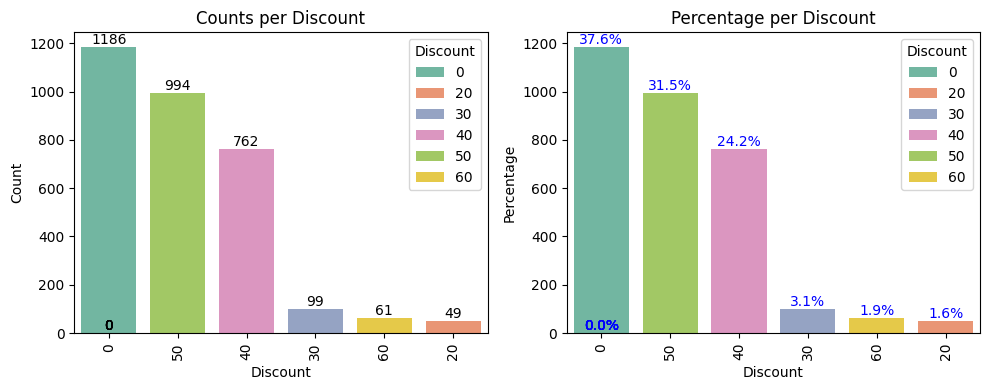

In [21]:
# let's explore discounts further
cat_analysis_count_and_perct(df, "Discount", figsize=(10, 4))

***Observations***

*37.6% of products did not have any discounts.*<br>
*More than 50% of the products have 40-50% discount.*

#### ***Bivariate Analysis***

***Checking for Correlations***

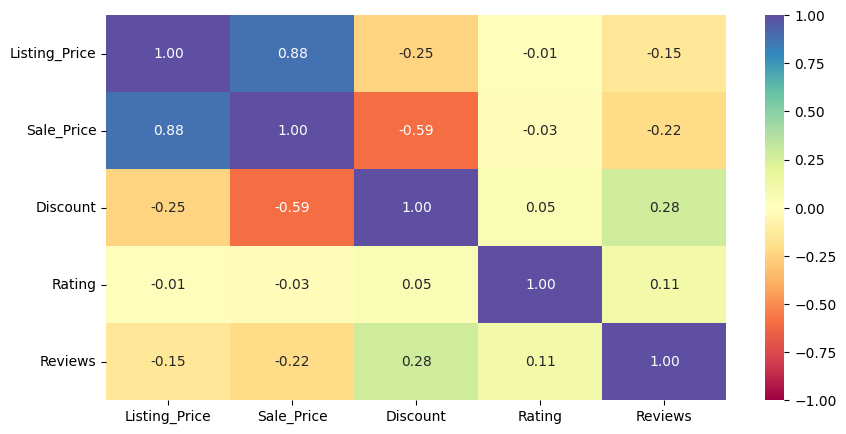

In [22]:
plt.figure(figsize=(10, 5))
sns.heatmap(df[num_col].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

***Observations***

- *The sale price and the listing price are highly positively correlated, which is obvious.*
- *Discount is somewhat negatively correlated with listing price or sale price, which indicates that expensive products either have fewer discounts or no discounts at all.*

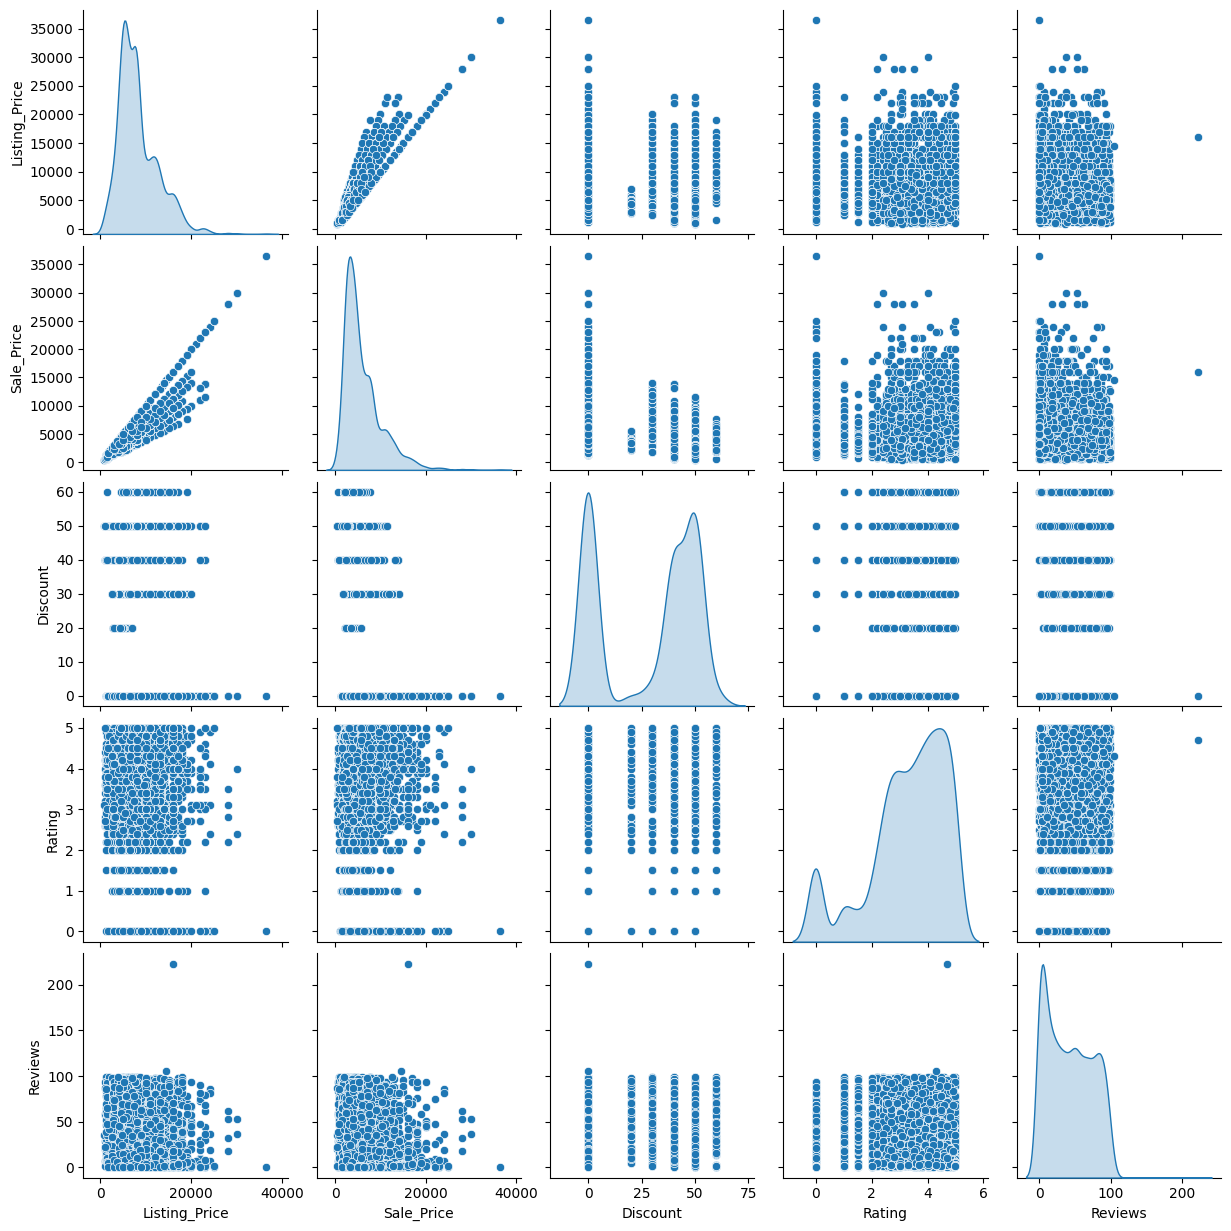

In [23]:
sns.pairplot(data=df[num_col], diag_kind="kde")
plt.show()

***KDE Plot clearly shows meaningful clusters across features***

#### ***Data Preprocessing***

In [24]:
# variables used for clustering
num_col

['Listing_Price', 'Sale_Price', 'Discount', 'Rating', 'Reviews']

In [25]:
# scaling the dataset before clustering
scaler = StandardScaler()
subset = df[num_col].copy()
subset_scaled = scaler.fit_transform(subset)

In [26]:
# creating a dataframe of the scaled columns
subset_scaled_df = pd.DataFrame(subset_scaled, columns=subset.columns)

#### ***Hierarchical Clustering***

***Find best combination of distance metrics and linkage method for hierarchical cluster - the one that yieids the highest cophenetic correlation coefficient***

In [27]:
# list of distance metrics

# euclidean - straight line distance between two points in n-dimensional space
# chebyshev - maximum absolute distance along any coordinate dimension
# mahalanobis - distance between a point and a distribution
# cityblock - sum of absolute differences (Manhattan distance)

distance_metrics = ["euclidean", "chebyshev", "mahalanobis", "cityblock"]

# list of linkage methods
linkage_methods = ["single", "complete", "average", "weighted"]

high_cophenet_corr = 0
high_dm_lm = [0, 0]

for dm in distance_metrics:
    for lm in linkage_methods:
        Z = linkage(subset_scaled_df, metric=dm, method=lm) # compute the linkage matrix - hierarchical clustering
        # Z is linkage matrix, array containing the hierarchical clustering information eg [cluster1, cluster2, distance, sample_count]

        c, coph_dists = cophenet(Z, pdist(subset_scaled_df)) # compute cophenetic correlation
        print(f"Cophenetic correlation for {dm.capitalize()} distance and {lm.capitalize()} linkage is {c}.")
        
        if high_cophenet_corr < c:
            high_cophenet_corr = c
            high_dm_lm[0] = dm
            high_dm_lm[1] = lm
    print() # just to add a line break after each distance metric

Cophenetic correlation for Euclidean distance and Single linkage is 0.6391818886918265.
Cophenetic correlation for Euclidean distance and Complete linkage is 0.716292465276334.
Cophenetic correlation for Euclidean distance and Average linkage is 0.7664519245950763.
Cophenetic correlation for Euclidean distance and Weighted linkage is 0.6047194146480935.

Cophenetic correlation for Chebyshev distance and Single linkage is 0.5854266041780848.
Cophenetic correlation for Chebyshev distance and Complete linkage is 0.6326026537632393.
Cophenetic correlation for Chebyshev distance and Average linkage is 0.7177631781172866.
Cophenetic correlation for Chebyshev distance and Weighted linkage is 0.5648124256800036.

Cophenetic correlation for Mahalanobis distance and Single linkage is 0.6325008742275653.
Cophenetic correlation for Mahalanobis distance and Complete linkage is 0.5637800085744984.
Cophenetic correlation for Mahalanobis distance and Average linkage is 0.7415915757776066.
Cophenetic c

In [28]:
# printing the combination of distance metric and linkage method with the highest cophenetic correlation
print("Highest cophenetic correlation is {}, which is obtained with {} distance and {} linkage.".format(
        high_cophenet_corr, high_dm_lm[0].capitalize(), high_dm_lm[1]
    )
)

Highest cophenetic correlation is 0.7790459489533398, which is obtained with Cityblock distance and average linkage.


***Let's explore different linkage methods with Euclidean distance only.***

In [29]:
# list of linkage methods
linkage_methods = ["single", "complete", "average", "centroid", "ward", "weighted"]

high_cophenet_corr = 0
high_dm_lm = [0, 0]

for lm in linkage_methods:
    Z = linkage(subset_scaled_df, metric="euclidean", method=lm)
    c, coph_dists = cophenet(Z, pdist(subset_scaled_df))
    print("Cophenetic correlation for {} linkage is {}.".format(lm, c))
    if high_cophenet_corr < c:
        high_cophenet_corr = c
        high_dm_lm[0] = "euclidean"
        high_dm_lm[1] = lm

Cophenetic correlation for single linkage is 0.6391818886918265.
Cophenetic correlation for complete linkage is 0.716292465276334.
Cophenetic correlation for average linkage is 0.7664519245950763.
Cophenetic correlation for centroid linkage is 0.7560310240211995.
Cophenetic correlation for ward linkage is 0.5416485654617125.
Cophenetic correlation for weighted linkage is 0.6047194146480935.


In [30]:
# printing the combination of distance metric and linkage method with the highest cophenetic correlation
print(
    "Highest cophenetic correlation is {}, which is obtained with {} linkage.".format(
        high_cophenet_corr, high_dm_lm[1]
    )
)

Highest cophenetic correlation is 0.7664519245950763, which is obtained with average linkage.


***Observations***

- *We see that the cophenetic correlation is maximum with cityblock distance, which is the Manhattan distance, and average linkage.*
- *The cophenetic correlation with Euclidean distance and average linkage is slightly less than the combination with maximum cophenetic correlation.* 


***Let's see the dendrograms for the different linkage methods.***

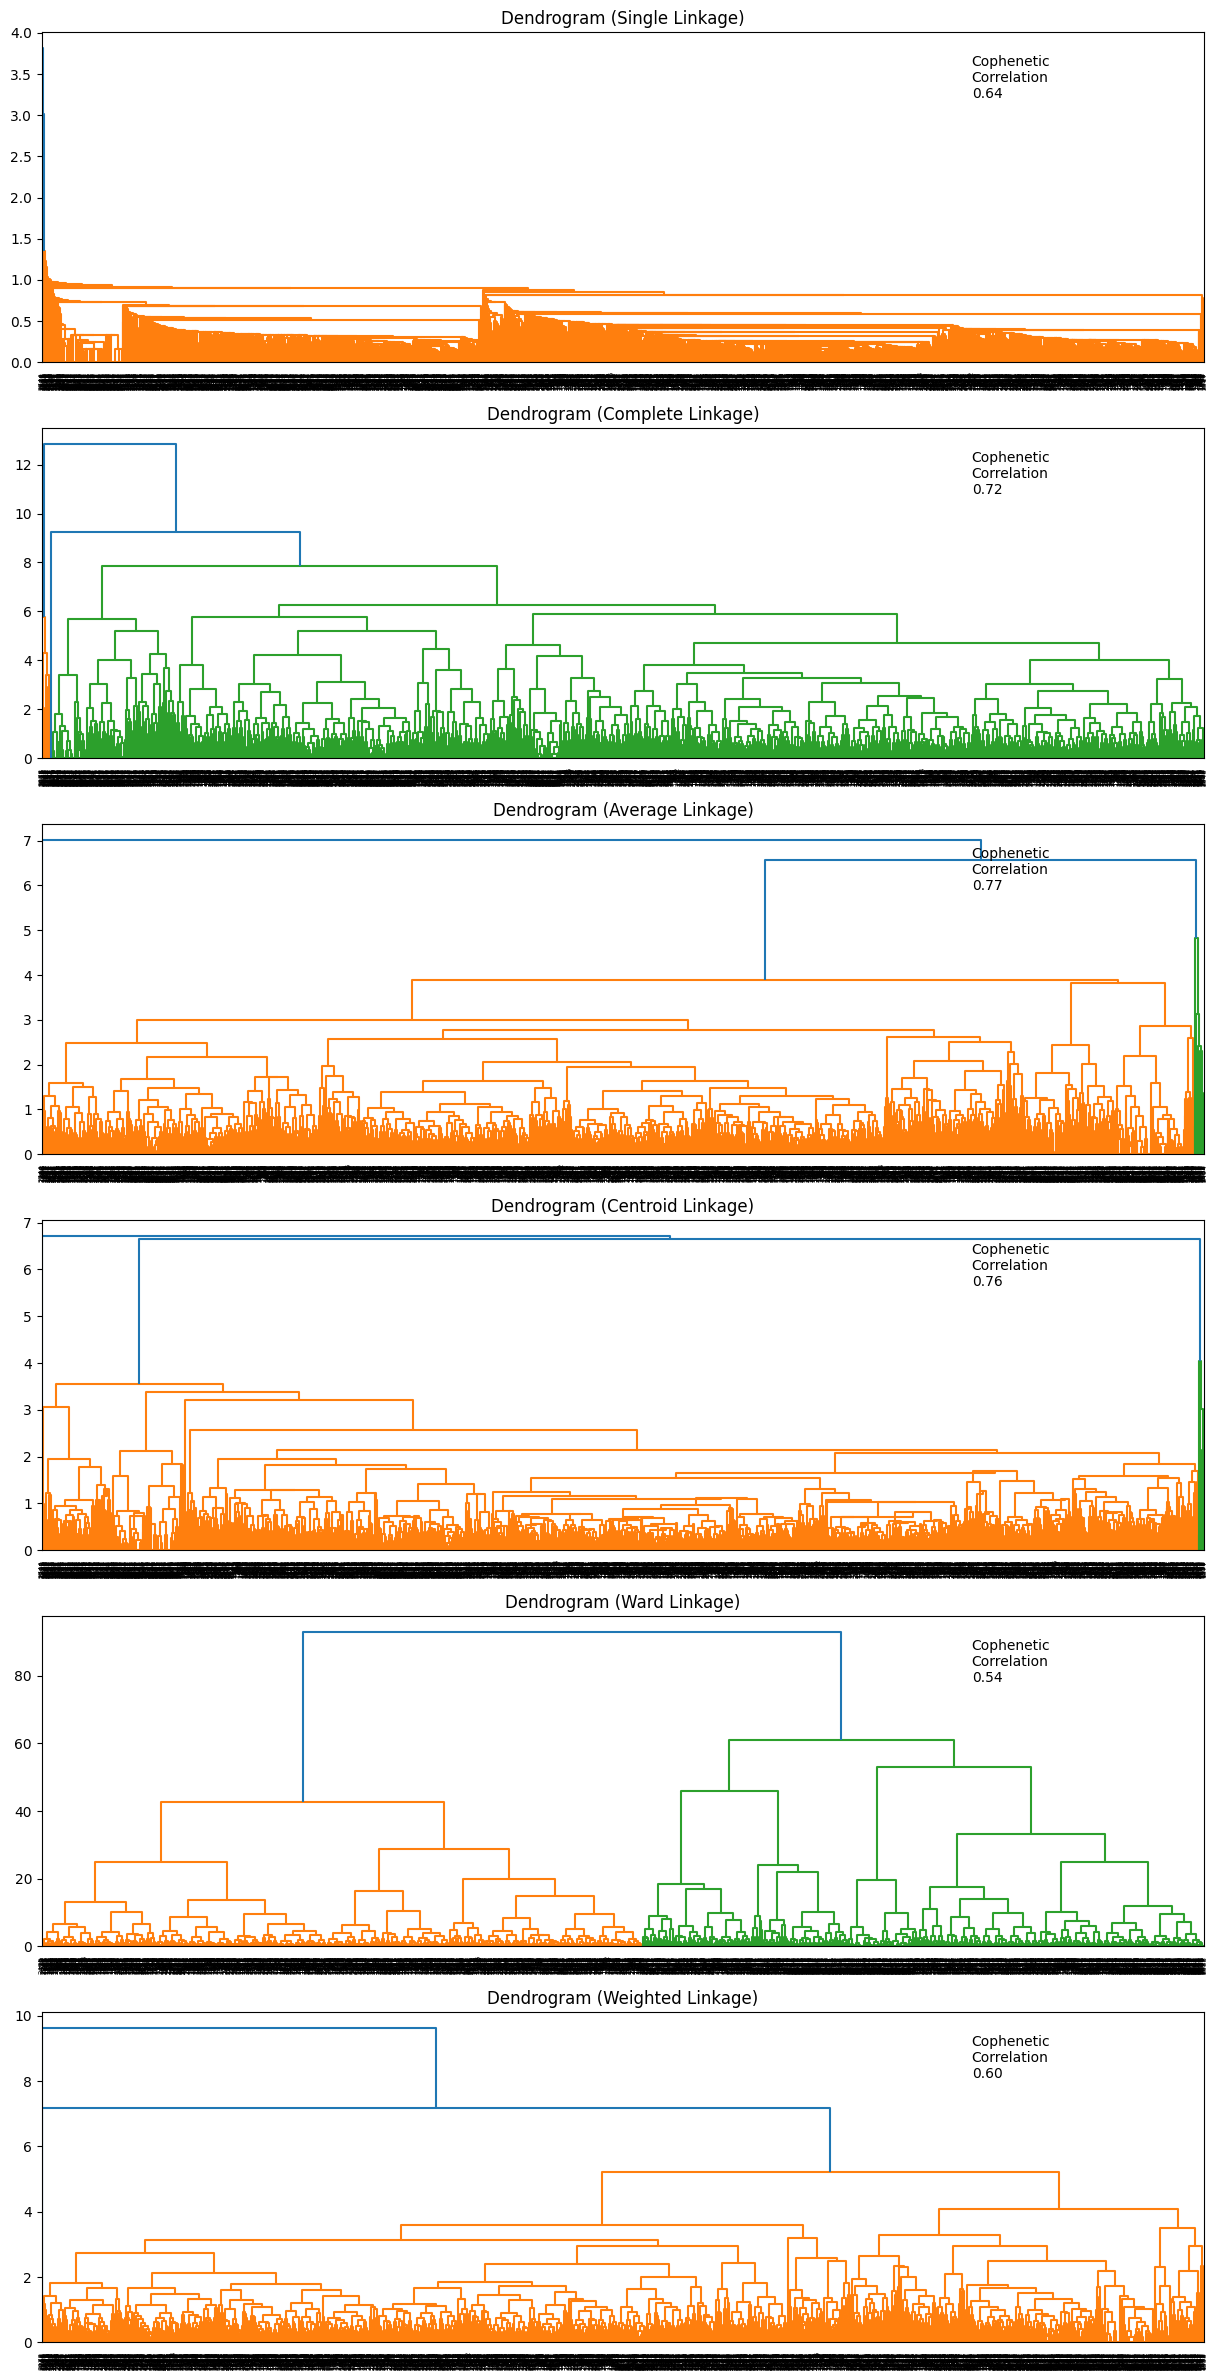

In [31]:
# list of linkage methods
linkage_methods = ["single", "complete", "average", "centroid", "ward", "weighted"]

# lists to save results of cophenetic correlation calculation
compare_cols = ["Linkage", "Cophenetic Coefficient"]
compare = []

# to create a subplot image
fig, axs = plt.subplots(len(linkage_methods), 1, figsize=(15, 30))

# We will enumerate through the list of linkage methods above
# For each linkage method, we will plot the dendrogram and calculate the cophenetic correlation
for i, method in enumerate(linkage_methods):
    Z = linkage(subset_scaled_df, metric="euclidean", method=method)

    dendrogram(Z, ax=axs[i])
    axs[i].set_title(f"Dendrogram ({method.capitalize()} Linkage)")

    coph_corr, coph_dist = cophenet(Z, pdist(subset_scaled_df))
    axs[i].annotate(
        f"Cophenetic\nCorrelation\n{coph_corr:0.2f}",
        (0.80, 0.80),
        xycoords="axes fraction",
    )

    compare.append([method, coph_corr])

***Observations***

- *Dendrogram for Ward linkage shows distinct and separate clusters.*

In [32]:
# let's create a dataframe to compare cophenetic correlations for each linkage method
df_cc = pd.DataFrame(compare, columns=compare_cols)
df_cc

,Linkage,Cophenetic Coefficient
0,single,0.639182
1,complete,0.716292
2,average,0.766452
3,centroid,0.756031
4,ward,0.541649
5,weighted,0.604719


***Let's see the dendrogram for Mahalanobis and Manhattan distances with average and weighted linkage methods (as they gave high cophenetic correlation values).***

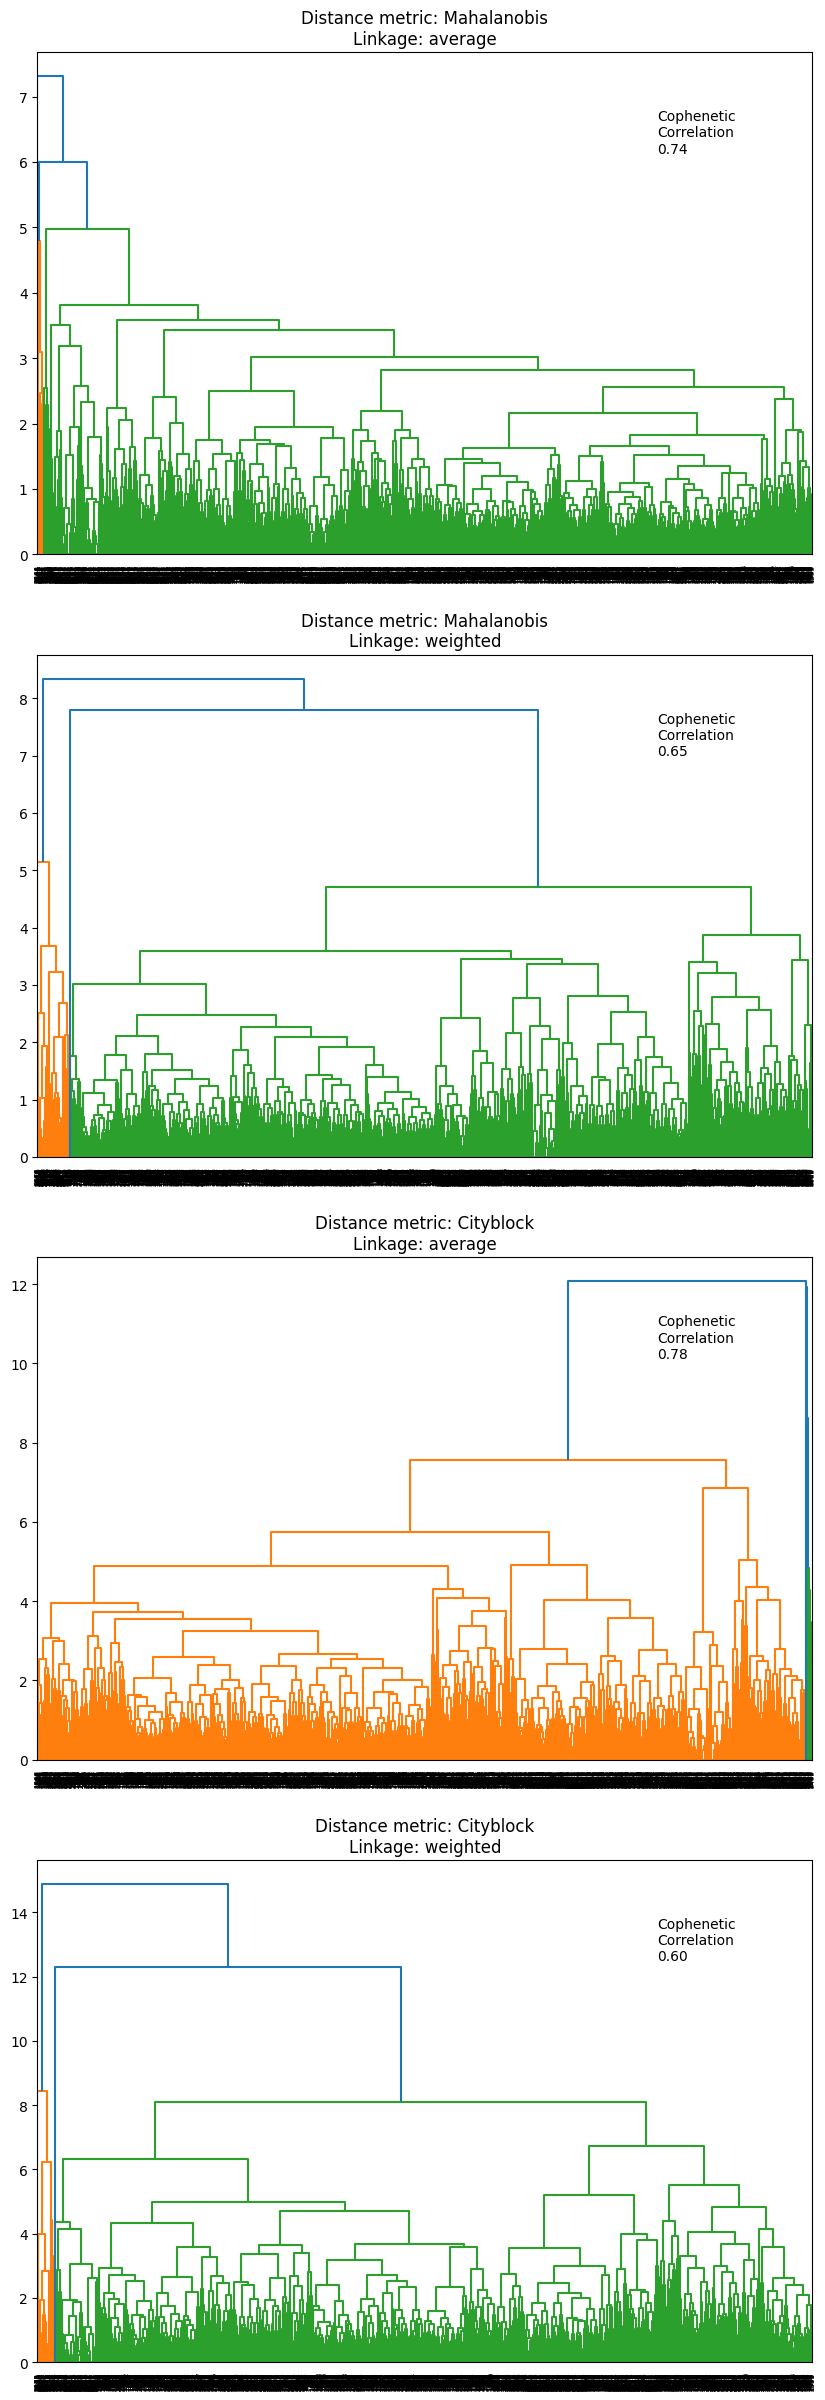

In [33]:
# list of distance metrics
distance_metrics = ["mahalanobis", "cityblock"]

# list of linkage methods
linkage_methods = ["average", "weighted"]

# to create a subplot image
fig, axs = plt.subplots(
    len(distance_metrics) + len(distance_metrics), 1, figsize=(10, 30)
)

i = 0
for dm in distance_metrics:
    for lm in linkage_methods:
        Z = linkage(subset_scaled_df, metric=dm, method=lm)

        dendrogram(Z, ax=axs[i])
        axs[i].set_title("Distance metric: {}\nLinkage: {}".format(dm.capitalize(), lm))

        coph_corr, coph_dist = cophenet(Z, pdist(subset_scaled_df))
        axs[i].annotate(
            f"Cophenetic\nCorrelation\n{coph_corr:0.2f}",
            (0.80, 0.80),
            xycoords="axes fraction",
        )
        i += 1

***Observations***

- *Out of all the dendrograms we saw, it is clear that the dendrogram with Ward linkage gave us separate and distinct clusters.*
- *3 would be the appropriate number of the clusters from the dendrogram with Ward linkage method.* 

***Let's create 3 clusters.***

In [34]:
HCmodel = AgglomerativeClustering(n_clusters=3, metric="euclidean", linkage="ward")
HCmodel.fit(subset_scaled_df)

,n_clusters,3
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [35]:
# adding hierarchical cluster labels to the original and scaled dataframes

subset_scaled_df["HC_Clusters"] = HCmodel.labels_
df["HC_Clusters"] = HCmodel.labels_

#### ***Cluster Profiling***

In [36]:
cluster_profile = df.select_dtypes(include=[np.number]).groupby("HC_Clusters").mean()

In [37]:
cluster_profile["count_in_each_segments"] = (
    df.groupby("HC_Clusters")["Sale_Price"].count().values
)

In [38]:
# let's display cluster profiles
cluster_profile.style.highlight_max(color="lightgreen", axis=0)

,Listing_Price,Sale_Price,Discount,Rating,Reviews,count_in_each_segments
HC_Clusters,,,,,,
0,7713.665285,7207.118135,0.891192,3.011295,30.126425,965
1,6188.557740,3358.597666,45.503686,3.347604,48.585995,1628
2,15138.686380,11523.822581,23.028674,3.579570,42.704301,558


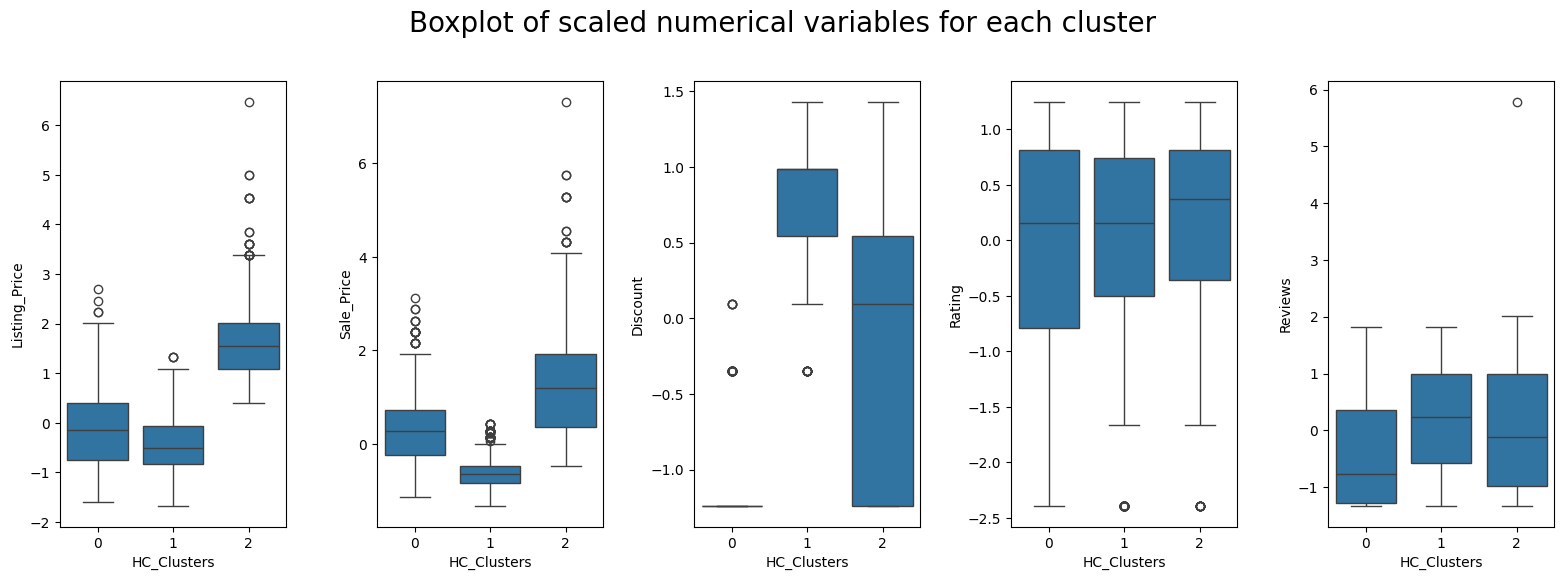

In [39]:
fig, axes = plt.subplots(1, 5, figsize=(16, 6))
fig.suptitle("Boxplot of scaled numerical variables for each cluster", fontsize=20)
counter = 0
for ii in range(5):
    sns.boxplot(
        ax=axes[ii],
        y=subset_scaled_df[num_col[counter]],
        x=subset_scaled_df["HC_Clusters"],
    )
    counter = counter + 1

fig.tight_layout(pad=2.0)

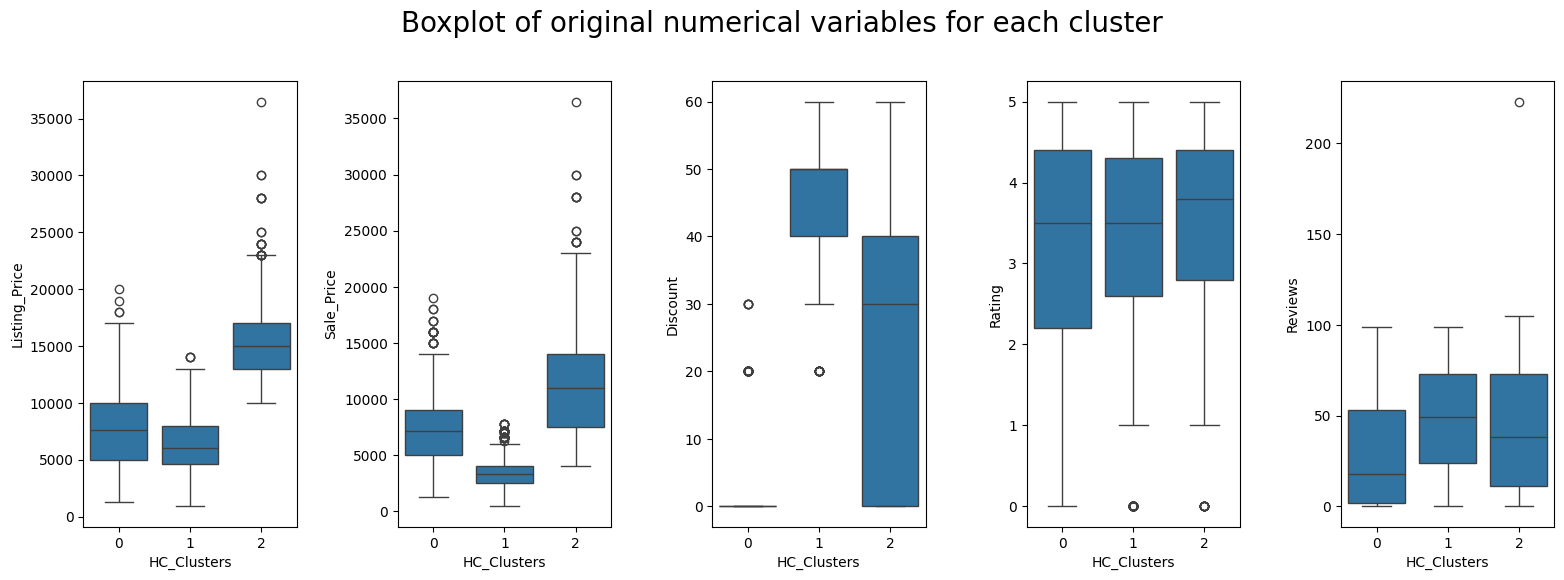

In [40]:
fig, axes = plt.subplots(1, 5, figsize=(16, 6))
fig.suptitle("Boxplot of original numerical variables for each cluster", fontsize=20)
counter = 0
for ii in range(5):
    sns.boxplot(ax=axes[ii], y=df[num_col[counter]], x=df["HC_Clusters"])
    counter = counter + 1

fig.tight_layout(pad=2.0)

***Insights***

***Cluster 0***:
- *This cluster contains medium-priced products, with a median listing price of approximately 7500.*
- *Almost no discount is given to products in these clusters.*
- *The median rating of this cluster is around 3.5, suggesting that customers are satisfied with 50% of the products in this cluster.*
- *Products in these clusters have got lesser reviews, which can be because these products are very expensive and fewer people buy them.*

***Cluster 1***:
- *Listing price is low for products in this cluster, and the sale price is lower, as there are heavier discounts on these products.*
- *Almost all the products have discounts between 30% to 40%.*
- *50% of products have a rating from 3.5 to 5 which indicates that customer satisfaction varies across products in this cluster.*
- *On average, 50 reviews are given to products in this cluster.*

***Cluster 2***:
- *This cluster contains more expensive premium products, with a median listing price of approximately 15000 and a median sale price of 11000.*
- *The discount for products in this cluster varies from 0% to 60%.*
- *Rating is very high.*

***Let's compare Cluster vs Brand***

In [41]:
pd.crosstab(df.HC_Clusters, df.Brand).style.highlight_max(color="lightgreen", axis=0)

Brand,Adidas Adidas ORIGINALS,Adidas CORE / NEO,Adidas ORIGINALS,Adidas SPORT PERFORMANCE,Nike
HC_Clusters,,,,,
0,0,249,214,115,387
1,0,861,469,298,0
2,1,1,223,193,140


***Observations***
- Adidas gives more discounts on their products, while Nike barely gives any.
- Nearly one-third of Nike products are premium in nature.

#### ***Business Recommendations***

- Cluster 2 consists of premium products, so focused marketing campaigns can be done to target customers with higher purchasing power.

- Cluster 2 products can also be made available in showrooms situated in premium locations because people generally tend to buy premium products from showrooms.

- Cluster 1 consists of products that are sold at higher discounts, so these might be the ones that are introduced in large quantity during festive sales (like Christmas, Black Friday, New Year, etc). This strategy can be continued with high inventory.

- Cluster 0 consists of products with comparatively low and medium prices with almost no discount, so general marketing campaigns can be done for these to target the general public.